# Chapter 9.2: Distributed Training for Recommendation Systems

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** the parameter server architecture and its advantages for embedding-heavy recommendation models
2. **Implement** AllReduce-based gradient synchronization for dense parameter training
3. **Design** model-parallel embedding table sharding strategies across multiple devices
4. **Compare** Meta's ZionEX, Persia, and HET (Tencent) distributed training platforms
5. **Analyze** the communication bottlenecks in distributed recommendation training
6. **Simulate** parameter server vs AllReduce trade-offs for different model configurations
7. **Apply** hybrid parallelism strategies combining data-parallel and model-parallel approaches

## Prerequisites

- Understanding of recommendation model architectures (embedding + MLP)
- Basic knowledge of distributed computing concepts
- PyTorch fundamentals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.2_distributed_training.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/blob/main/notebooks/part9/chapter_9.2_distributed_training.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import copy

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.2.2


## 1. The Distributed Training Challenge for RecSys

Recommendation models present unique challenges for distributed training compared to vision or NLP models:

| Aspect | Vision/NLP | RecSys |
|--------|-----------|--------|
| **Model Size** | Mostly dense parameters | Huge sparse embeddings (TBs) |
| **Memory** | Model fits on one GPU | Embedding tables too large for one GPU |
| **Gradient Sparsity** | Dense gradients | Only accessed embeddings get gradients |
| **Communication** | AllReduce on dense tensors | Sparse lookups + dense sync |
| **Throughput** | Compute-bound | Memory/communication-bound |

A typical production recommendation model at Meta or Google:
- **Embedding tables**: 10-100 tables, each with millions to billions of rows
- **Total embedding size**: 1-10 TB
- **Dense MLP**: 10-100 MB (tiny compared to embeddings)
- **Training throughput**: Millions of samples per second

### Two Fundamental Approaches

**Data Parallelism (AllReduce)**: Each worker has a full model copy. Works well for dense parameters but wasteful for sparse embeddings.

**Model Parallelism (Parameter Server / Sharding)**: Partition the embedding tables across workers. Each worker holds a shard and serves embedding lookups.

> **💡 Concept:** In practice, production systems use **hybrid parallelism**: model-parallel for embedding tables (sharded across GPUs) and data-parallel for the dense MLP layers (replicated with AllReduce).

In [2]:
# Simulate the scale of a production recommendation model

class RecModelProfile:
    """Analyze the memory and communication profile of a rec model."""
    
    def __init__(self, embedding_tables: List[Tuple[int, int]], mlp_layers: List[int]):
        """
        Args:
            embedding_tables: List of (num_rows, embedding_dim) for each table
            mlp_layers: List of MLP layer widths
        """
        self.embedding_tables = embedding_tables
        self.mlp_layers = mlp_layers
    
    def embedding_memory_gb(self) -> float:
        total_params = sum(rows * dim for rows, dim in self.embedding_tables)
        return total_params * 4 / (1024 ** 3)  # FP32 = 4 bytes
    
    def mlp_memory_gb(self) -> float:
        total_params = 0
        for i in range(1, len(self.mlp_layers)):
            total_params += self.mlp_layers[i-1] * self.mlp_layers[i] + self.mlp_layers[i]
        return total_params * 4 / (1024 ** 3)
    
    def report(self):
        emb_gb = self.embedding_memory_gb()
        mlp_gb = self.mlp_memory_gb()
        total = emb_gb + mlp_gb
        print(f"=== Model Memory Profile ===")
        print(f"Embedding tables: {len(self.embedding_tables)}")
        print(f"  Total rows: {sum(r for r, _ in self.embedding_tables):,.0f}")
        print(f"  Memory: {emb_gb:.2f} GB ({emb_gb/total*100:.1f}%)")
        print(f"MLP layers: {self.mlp_layers}")
        print(f"  Memory: {mlp_gb*1024:.2f} MB ({mlp_gb/total*100:.1f}%)")
        print(f"Total: {total:.2f} GB")
        print(f"\nGPU requirement (A100 80GB): {int(np.ceil(total / 70))} GPUs minimum")


# DLRM-scale model profile (Meta-style)
embedding_tables = [
    (10_000_000, 64),   # User ID
    (50_000_000, 64),   # Item ID
    (1_000_000, 32),    # Category
    (500_000, 32),      # Brand
    (100_000, 16),      # City
    (10_000, 16),       # Device type
    (1_000, 8),         # OS
    (500, 8),           # Browser
    (200_000_000, 64),  # Feature cross 1
    (100_000_000, 64),  # Feature cross 2
]

mlp_layers = [512, 256, 128, 64, 1]

profile = RecModelProfile(embedding_tables, mlp_layers)
profile.report()

=== Model Memory Profile ===
Embedding tables: 10
  Total rows: 361,611,500
  Memory: 86.02 GB (100.0%)
MLP layers: [512, 256, 128, 64, 1]
  Memory: 0.66 MB (0.0%)
Total: 86.02 GB

GPU requirement (A100 80GB): 2 GPUs minimum


## 2. Parameter Server Architecture

The **Parameter Server** (PS) architecture (Li et al., 2014) is the classic approach for distributed training with large embedding tables.

### Architecture

- **Server nodes** store shards of the embedding tables
- **Worker nodes** compute forward/backward passes
- Workers **pull** embeddings from servers, compute gradients, and **push** updates back

### Communication Pattern

For a batch with $B$ samples and embedding dimension $d$:

$$\text{Pull volume} = B \times K \times d \times 4 \text{ bytes}$$
$$\text{Push volume} = |\text{unique\_ids}| \times d \times 4 \text{ bytes}$$

where $K$ is the number of embedding tables accessed per sample.

> **⚠️ Common Pitfall:** The parameter server can become a bottleneck when embedding access patterns are skewed (hot items). Consistent hashing and load balancing are essential.

In [3]:
class SimulatedParameterServer:
    """Simulates a parameter server for embedding tables."""
    
    def __init__(self, num_shards: int, num_items: int, embedding_dim: int):
        self.num_shards = num_shards
        self.embedding_dim = embedding_dim
        
        # Shard embeddings across servers using modular hashing
        self.shards = {}
        shard_size = (num_items + num_shards - 1) // num_shards
        for s in range(num_shards):
            start = s * shard_size
            end = min(start + shard_size, num_items)
            self.shards[s] = nn.Embedding(end - start, embedding_dim)
            nn.init.xavier_uniform_(self.shards[s].weight)
        
        self.shard_size = shard_size
        self.pull_bytes = 0
        self.push_bytes = 0
        self.num_pulls = 0
        self.num_pushes = 0
    
    def _get_shard(self, item_id: int) -> Tuple[int, int]:
        """Map item ID to (shard_id, local_index)."""
        shard_id = item_id // self.shard_size
        local_idx = item_id % self.shard_size
        return min(shard_id, self.num_shards - 1), local_idx
    
    def pull(self, item_ids: torch.Tensor) -> torch.Tensor:
        """Pull embeddings from parameter servers."""
        embeddings = []
        for item_id in item_ids:
            shard_id, local_idx = self._get_shard(item_id.item())
            local_idx = min(local_idx, self.shards[shard_id].weight.size(0) - 1)
            emb = self.shards[shard_id](torch.tensor([local_idx]))
            embeddings.append(emb)
        
        result = torch.cat(embeddings, dim=0)
        self.pull_bytes += result.numel() * 4
        self.num_pulls += 1
        return result
    
    def push(self, item_ids: torch.Tensor, gradients: torch.Tensor, lr: float = 0.01):
        """Push gradient updates to parameter servers."""
        with torch.no_grad():
            for i, item_id in enumerate(item_ids):
                shard_id, local_idx = self._get_shard(item_id.item())
                local_idx = min(local_idx, self.shards[shard_id].weight.size(0) - 1)
                self.shards[shard_id].weight[local_idx] -= lr * gradients[i]
        
        unique_ids = len(set(item_ids.tolist()))
        self.push_bytes += unique_ids * self.embedding_dim * 4
        self.num_pushes += 1
    
    def get_comm_stats(self) -> Dict:
        return {
            'total_pull_MB': self.pull_bytes / (1024 ** 2),
            'total_push_MB': self.push_bytes / (1024 ** 2),
            'num_pulls': self.num_pulls,
            'num_pushes': self.num_pushes
        }


# Demo
NUM_ITEMS_SMALL = 100000
EMB_DIM = 64
ps = SimulatedParameterServer(num_shards=4, num_items=NUM_ITEMS_SMALL, embedding_dim=EMB_DIM)

# Simulate a training step
batch_items = torch.randint(0, NUM_ITEMS_SMALL, (256,))
embeddings = ps.pull(batch_items)
fake_grads = torch.randn_like(embeddings)
ps.push(batch_items, fake_grads)

stats = ps.get_comm_stats()
print(f"Communication stats after 1 batch:")
for k, v in stats.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Communication stats after 1 batch:
  total_pull_MB: 0.0625
  total_push_MB: 0.0625
  num_pulls: 1
  num_pushes: 1


## 3. AllReduce for Dense Parameter Synchronization

For the dense MLP layers in recommendation models, **AllReduce** is the standard synchronization primitive. Each worker computes local gradients, then AllReduce aggregates them across all workers.

### Ring AllReduce

The ring AllReduce algorithm has communication cost:

$$T_{\text{ring}} = 2 \cdot (N-1) \cdot \frac{M}{N} \cdot \frac{1}{B}$$

where $N$ is the number of workers, $M$ is the tensor size in bytes, and $B$ is the bandwidth per link.

The key advantage: communication cost scales with $(N-1)/N \approx 1$ regardless of the number of workers — **communication does not increase with more workers**.

> **🔑 Pro Tip:** In practice, gradient compression (top-K sparsification, quantization) can reduce AllReduce communication by 10-100x with minimal quality loss. This is especially effective for the MLP gradients in rec models.

In [4]:
class SimulatedAllReduce:
    """Simulates AllReduce gradient synchronization across workers."""
    
    def __init__(self, num_workers: int, bandwidth_gbps: float = 100.0):
        self.num_workers = num_workers
        self.bandwidth_bytes_per_sec = bandwidth_gbps * 1e9 / 8  # Convert to bytes/sec
        self.total_comm_bytes = 0
        self.total_comm_time = 0
    
    def allreduce(self, local_gradients: List[torch.Tensor]) -> torch.Tensor:
        """
        Simulate ring AllReduce: average gradients across workers.
        """
        assert len(local_gradients) == self.num_workers
        
        # Compute average
        result = torch.zeros_like(local_gradients[0])
        for g in local_gradients:
            result += g
        result /= self.num_workers
        
        # Compute communication cost (ring AllReduce)
        tensor_bytes = local_gradients[0].numel() * 4  # FP32
        # Ring AllReduce: 2*(N-1)/N * M bytes total
        comm_bytes = 2 * (self.num_workers - 1) / self.num_workers * tensor_bytes
        comm_time = comm_bytes / self.bandwidth_bytes_per_sec
        
        self.total_comm_bytes += comm_bytes
        self.total_comm_time += comm_time
        
        return result
    
    def get_stats(self) -> Dict:
        return {
            'total_comm_MB': self.total_comm_bytes / (1024 ** 2),
            'total_comm_time_ms': self.total_comm_time * 1000,
        }


# Compare communication costs for different numbers of workers
mlp_param_count = sum(
    mlp_layers[i] * mlp_layers[i+1] + mlp_layers[i+1] 
    for i in range(len(mlp_layers) - 1)
)

print(f"MLP parameter count: {mlp_param_count:,}")

worker_configs = [2, 4, 8, 16, 32]
comm_costs = []

for nw in worker_configs:
    ar = SimulatedAllReduce(num_workers=nw, bandwidth_gbps=100.0)
    # Simulate 100 training steps
    for _ in range(100):
        grads = [torch.randn(mlp_param_count) for _ in range(nw)]
        _ = ar.allreduce(grads)
    stats = ar.get_stats()
    comm_costs.append(stats['total_comm_time_ms'])
    print(f"Workers={nw:2d}: Comm={stats['total_comm_MB']:.1f} MB, Time={stats['total_comm_time_ms']:.2f} ms")

# The key insight: comm cost barely grows with workers for ring AllReduce
print(f"\nCost ratio (32 workers / 2 workers): {comm_costs[-1] / comm_costs[0]:.2f}x")
print("(Ring AllReduce scales as (N-1)/N, approaching 1.0)")

MLP parameter count: 172,545


Workers= 2: Comm=65.8 MB, Time=5.52 ms


Workers= 4: Comm=98.7 MB, Time=8.28 ms


Workers= 8: Comm=115.2 MB, Time=9.66 ms


Workers=16: Comm=123.4 MB, Time=10.35 ms


Workers=32: Comm=127.5 MB, Time=10.70 ms

Cost ratio (32 workers / 2 workers): 1.94x
(Ring AllReduce scales as (N-1)/N, approaching 1.0)


## 4. Model-Parallel Embeddings: Table Sharding

When embedding tables are too large for a single GPU, we must **shard** them across multiple devices. Several strategies exist:

### Sharding Strategies

1. **Table-wise sharding**: Each table on a different GPU. Simple but unbalanced (tables have different sizes).
2. **Row-wise sharding**: Rows of a table split across GPUs. Balanced but requires all-to-all communication.
3. **Column-wise sharding**: Embedding dimensions split across GPUs. Rarely used alone.
4. **Hybrid sharding**: Small tables replicated, large tables row-sharded. Used in TorchRec (Meta).

### All-to-All Communication

Row-wise sharding requires **all-to-all** communication: each worker needs embeddings from potentially all shards.

$$\text{All-to-All cost} = B \times K \times d \times \frac{N-1}{N}$$

where $B$ is batch size, $K$ is lookups per sample, $d$ is embedding dim, $N$ is number of GPUs.

> **💡 Concept:** TorchRec's `EmbeddingBagCollection` planner automatically determines the optimal sharding strategy by solving a mixed-integer program that minimizes peak memory and communication cost.

In [5]:
class EmbeddingShardPlanner:
    """Plan embedding table sharding across GPUs."""
    
    def __init__(self, num_gpus: int, gpu_memory_gb: float = 80.0):
        self.num_gpus = num_gpus
        self.gpu_memory_bytes = gpu_memory_gb * (1024 ** 3)
    
    def table_wise_plan(self, tables: List[Tuple[str, int, int]]) -> Dict[int, List[str]]:
        """
        Greedy table-wise sharding: assign each table to the GPU with most free memory.
        tables: List of (name, num_rows, embedding_dim)
        """
        gpu_usage = [0.0] * self.num_gpus
        assignment = defaultdict(list)
        
        # Sort tables by size (largest first) for better bin packing
        sorted_tables = sorted(tables, key=lambda t: t[1] * t[2], reverse=True)
        
        for name, rows, dim in sorted_tables:
            table_bytes = rows * dim * 4  # FP32
            # Assign to GPU with least usage
            min_gpu = min(range(self.num_gpus), key=lambda g: gpu_usage[g])
            gpu_usage[min_gpu] += table_bytes
            assignment[min_gpu].append(name)
        
        return dict(assignment), gpu_usage
    
    def row_wise_plan(self, tables: List[Tuple[str, int, int]]) -> Dict:
        """
        Row-wise sharding: split each large table's rows evenly across GPUs.
        Small tables are replicated.
        """
        REPLICATE_THRESHOLD_MB = 100  # Replicate tables smaller than this
        plan = {}
        gpu_usage = [0.0] * self.num_gpus
        
        for name, rows, dim in tables:
            table_bytes = rows * dim * 4
            table_mb = table_bytes / (1024 ** 2)
            
            if table_mb < REPLICATE_THRESHOLD_MB:
                plan[name] = {'strategy': 'replicate', 'gpus': list(range(self.num_gpus))}
                for g in range(self.num_gpus):
                    gpu_usage[g] += table_bytes
            else:
                rows_per_gpu = (rows + self.num_gpus - 1) // self.num_gpus
                plan[name] = {
                    'strategy': 'row_wise',
                    'rows_per_gpu': rows_per_gpu,
                    'gpus': list(range(self.num_gpus))
                }
                for g in range(self.num_gpus):
                    gpu_usage[g] += rows_per_gpu * dim * 4
        
        return plan, gpu_usage


# Plan sharding for our model
tables = [
    ('user_id', 10_000_000, 64),
    ('item_id', 50_000_000, 64),
    ('category', 1_000_000, 32),
    ('brand', 500_000, 32),
    ('city', 100_000, 16),
    ('device', 10_000, 16),
    ('os', 1_000, 8),
    ('browser', 500, 8),
    ('cross_1', 200_000_000, 64),
    ('cross_2', 100_000_000, 64),
]

planner = EmbeddingShardPlanner(num_gpus=8, gpu_memory_gb=80.0)

print("=== Table-wise Sharding ===")
tw_plan, tw_usage = planner.table_wise_plan(tables)
for gpu_id, table_names in sorted(tw_plan.items()):
    print(f"  GPU {gpu_id}: {table_names} ({tw_usage[gpu_id]/(1024**3):.2f} GB)")

print(f"\n  Max GPU memory: {max(tw_usage)/(1024**3):.2f} GB")
print(f"  Memory imbalance: {max(tw_usage)/max(min(tw_usage), 1):.2f}x")

print("\n=== Row-wise Sharding (hybrid) ===")
rw_plan, rw_usage = planner.row_wise_plan(tables)
for name, info in rw_plan.items():
    print(f"  {name}: {info['strategy']}")
print(f"\n  Max GPU memory: {max(rw_usage)/(1024**3):.2f} GB")
print(f"  Memory imbalance: {max(rw_usage)/max(min(rw_usage), 1):.2f}x")

=== Table-wise Sharding ===
  GPU 0: ['cross_1'] (47.68 GB)
  GPU 1: ['cross_2'] (23.84 GB)
  GPU 2: ['item_id'] (11.92 GB)
  GPU 3: ['user_id'] (2.38 GB)
  GPU 4: ['category'] (0.12 GB)
  GPU 5: ['brand'] (0.06 GB)
  GPU 6: ['city'] (0.01 GB)
  GPU 7: ['device', 'os', 'browser'] (0.00 GB)

  Max GPU memory: 47.68 GB
  Memory imbalance: 74418.60x

=== Row-wise Sharding (hybrid) ===
  user_id: row_wise
  item_id: row_wise
  category: row_wise
  brand: replicate
  city: replicate
  device: replicate
  os: replicate
  browser: replicate
  cross_1: row_wise
  cross_2: row_wise

  Max GPU memory: 10.81 GB
  Memory imbalance: 1.00x


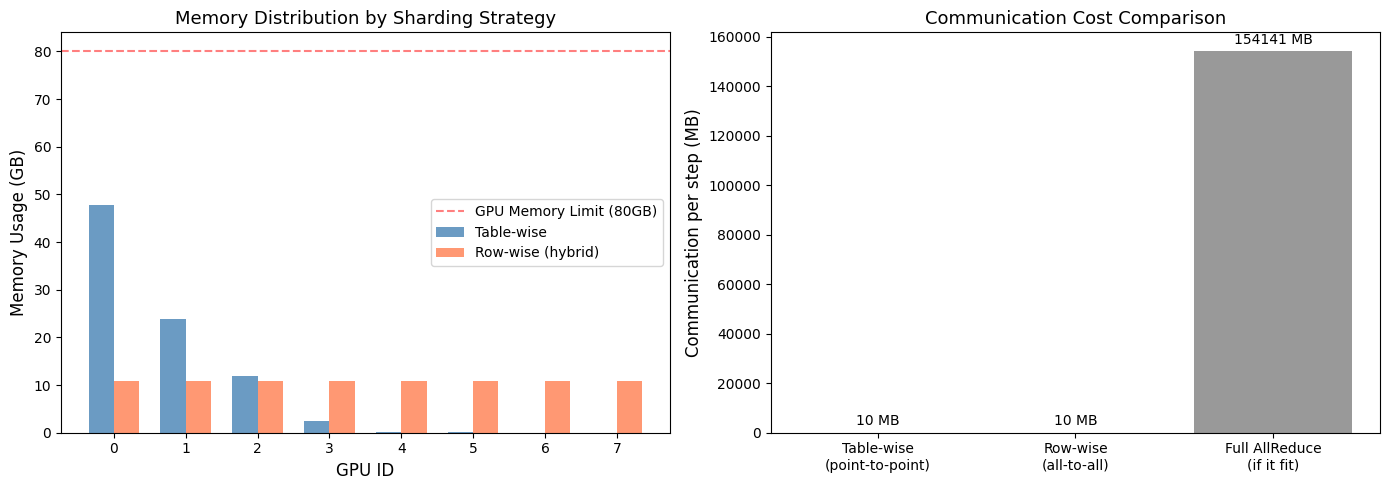

In [6]:
# Visualize sharding strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Table-wise memory distribution
gpus = list(range(8))
tw_mem = [tw_usage[g] / (1024**3) for g in gpus]
rw_mem = [rw_usage[g] / (1024**3) for g in gpus]

x = np.arange(8)
width = 0.35
axes[0].bar(x - width/2, tw_mem, width, label='Table-wise', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, rw_mem, width, label='Row-wise (hybrid)', color='coral', alpha=0.8)
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='GPU Memory Limit (80GB)')
axes[0].set_xlabel('GPU ID', fontsize=12)
axes[0].set_ylabel('Memory Usage (GB)', fontsize=12)
axes[0].set_title('Memory Distribution by Sharding Strategy', fontsize=13)
axes[0].legend()
axes[0].set_xticks(x)

# Communication cost comparison
batch_size = 4096
num_tables = len(tables)
avg_emb_dim = np.mean([d for _, _, d in tables])

# Table-wise: need point-to-point for each table not on local GPU
tw_comm = batch_size * avg_emb_dim * 4 * (num_tables - num_tables / 8) * 2  # fwd + bwd
# Row-wise: need all-to-all
rw_comm = batch_size * avg_emb_dim * 4 * num_tables * (7/8) * 2  # all-to-all fwd + bwd
# AllReduce only (baseline with replicated embeddings - if it fit)
ar_comm = sum(r * d for _, r, d in tables) * 4 * 2 * (7/8)  # full gradient AllReduce

comm_names = ['Table-wise\n(point-to-point)', 'Row-wise\n(all-to-all)', 'Full AllReduce\n(if it fit)']
comm_values = [tw_comm / (1024**2), rw_comm / (1024**2), ar_comm / (1024**2)]

colors = ['steelblue', 'coral', 'gray']
axes[1].bar(comm_names, comm_values, color=colors, alpha=0.8)
axes[1].set_ylabel('Communication per step (MB)', fontsize=12)
axes[1].set_title('Communication Cost Comparison', fontsize=13)
for i, v in enumerate(comm_values):
    axes[1].text(i, v + max(comm_values)*0.02, f'{v:.0f} MB', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Production Training Platforms

### Meta's ZionEX (2022)
- Custom hardware designed for recommendation training
- Disaggregated memory: CPU memory pools for embedding tables, GPU for compute
- Unified training platform for all recommendation models at Meta
- Key insight: treat embedding lookups as a memory subsystem problem, not a compute problem

### Persia (Luo et al., 2022)
- Open-source hybrid training system from Kuaishou (Chinese short-video platform)
- Separates embedding parameters (on CPU) from dense parameters (on GPU)
- Asynchronous embedding updates with bounded staleness
- Achieves near-linear scaling up to 100 GPUs

### HET — Tencent (Liang et al., 2022)
- Highly Efficient Training for embedding models
- Hierarchical embedding table: hot embeddings on GPU, cold on CPU, frozen on SSD
- Dynamic migration based on access frequency
- Achieves 3-10x speedup over standard PS architectures

> **🔑 Pro Tip:** The trend in production systems is toward **heterogeneous memory architectures** that place hot embeddings in GPU HBM and cold embeddings in CPU DRAM or even SSD, dynamically migrating based on access patterns.

In [7]:
class HierarchicalEmbeddingTable:
    """
    Simulates HET-style hierarchical embedding storage.
    Hot embeddings in 'GPU' (fast), warm in 'CPU' (medium), cold in 'SSD' (slow).
    """
    
    def __init__(self, num_items: int, embedding_dim: int,
                 gpu_capacity: int = 10000, cpu_capacity: int = 100000):
        self.embedding_dim = embedding_dim
        self.gpu_capacity = gpu_capacity
        self.cpu_capacity = cpu_capacity
        
        # All embeddings stored in a flat tensor (simulating SSD backing store)
        self.all_embeddings = torch.randn(num_items, embedding_dim) * 0.01
        
        # Tier tracking
        self.access_counts = defaultdict(int)
        self.gpu_cache = {}   # id -> embedding (fast)
        self.cpu_cache = {}   # id -> embedding (medium)
        
        # Latency simulation (relative units)
        self.gpu_latency = 0.001  # ms per lookup
        self.cpu_latency = 0.01
        self.ssd_latency = 0.1
        self.total_latency = 0
        self.tier_hits = {'gpu': 0, 'cpu': 0, 'ssd': 0}
    
    def lookup(self, item_ids: List[int]) -> torch.Tensor:
        """Look up embeddings with hierarchical caching."""
        embeddings = []
        for item_id in item_ids:
            self.access_counts[item_id] += 1
            
            if item_id in self.gpu_cache:
                embeddings.append(self.gpu_cache[item_id])
                self.total_latency += self.gpu_latency
                self.tier_hits['gpu'] += 1
            elif item_id in self.cpu_cache:
                emb = self.cpu_cache[item_id]
                embeddings.append(emb)
                self.total_latency += self.cpu_latency
                self.tier_hits['cpu'] += 1
                # Promote to GPU if there's space
                if len(self.gpu_cache) < self.gpu_capacity:
                    self.gpu_cache[item_id] = emb
            else:
                emb = self.all_embeddings[item_id].clone()
                embeddings.append(emb)
                self.total_latency += self.ssd_latency
                self.tier_hits['ssd'] += 1
                # Add to CPU cache
                if len(self.cpu_cache) < self.cpu_capacity:
                    self.cpu_cache[item_id] = emb
        
        return torch.stack(embeddings)
    
    def rebalance(self):
        """Promote/demote embeddings based on access frequency."""
        # Sort by access count
        sorted_items = sorted(self.access_counts.items(), key=lambda x: x[1], reverse=True)
        
        self.gpu_cache.clear()
        self.cpu_cache.clear()
        
        for rank, (item_id, _) in enumerate(sorted_items):
            emb = self.all_embeddings[item_id].clone()
            if rank < self.gpu_capacity:
                self.gpu_cache[item_id] = emb
            elif rank < self.gpu_capacity + self.cpu_capacity:
                self.cpu_cache[item_id] = emb


# Simulate with Zipf-distributed access pattern
het = HierarchicalEmbeddingTable(
    num_items=1_000_000, embedding_dim=64,
    gpu_capacity=10000, cpu_capacity=100000
)

# Phase 1: Cold start (no caching)
zipf_items = np.random.zipf(a=1.5, size=100000) - 1
zipf_items = np.clip(zipf_items, 0, 999999)

for batch_start in range(0, 50000, 256):
    batch = zipf_items[batch_start:batch_start + 256].tolist()
    _ = het.lookup(batch)

print("Phase 1 (before rebalance):")
print(f"  Tier hits: {het.tier_hits}")
total_hits = sum(het.tier_hits.values())
print(f"  GPU hit rate: {het.tier_hits['gpu']/total_hits:.1%}")

# Rebalance based on access patterns
het.rebalance()
het.tier_hits = {'gpu': 0, 'cpu': 0, 'ssd': 0}
het.total_latency = 0

# Phase 2: After rebalance
for batch_start in range(50000, 100000, 256):
    batch = zipf_items[batch_start:batch_start + 256].tolist()
    _ = het.lookup(batch)

print("\nPhase 2 (after rebalance):")
print(f"  Tier hits: {het.tier_hits}")
total_hits = sum(het.tier_hits.values())
print(f"  GPU hit rate: {het.tier_hits['gpu']/total_hits:.1%}")
print(f"  CPU hit rate: {het.tier_hits['cpu']/total_hits:.1%}")

Phase 1 (before rebalance):
  Tier hits: {'gpu': 47698, 'cpu': 629, 'ssd': 1849}
  GPU hit rate: 95.1%

Phase 2 (after rebalance):
  Tier hits: {'gpu': 48723, 'cpu': 98, 'ssd': 1179}
  GPU hit rate: 97.4%
  CPU hit rate: 0.2%


## 6. Simulating PS vs AllReduce Trade-offs

Let us build a comprehensive simulator to compare parameter server and AllReduce approaches across different model configurations and cluster sizes.

The key insight is that the optimal strategy depends on:
- **Embedding sparsity**: How many unique embeddings are accessed per batch
- **Cluster size**: More workers favor AllReduce for dense, PS for sparse
- **Network bandwidth**: Low bandwidth favors sparse communication (PS)

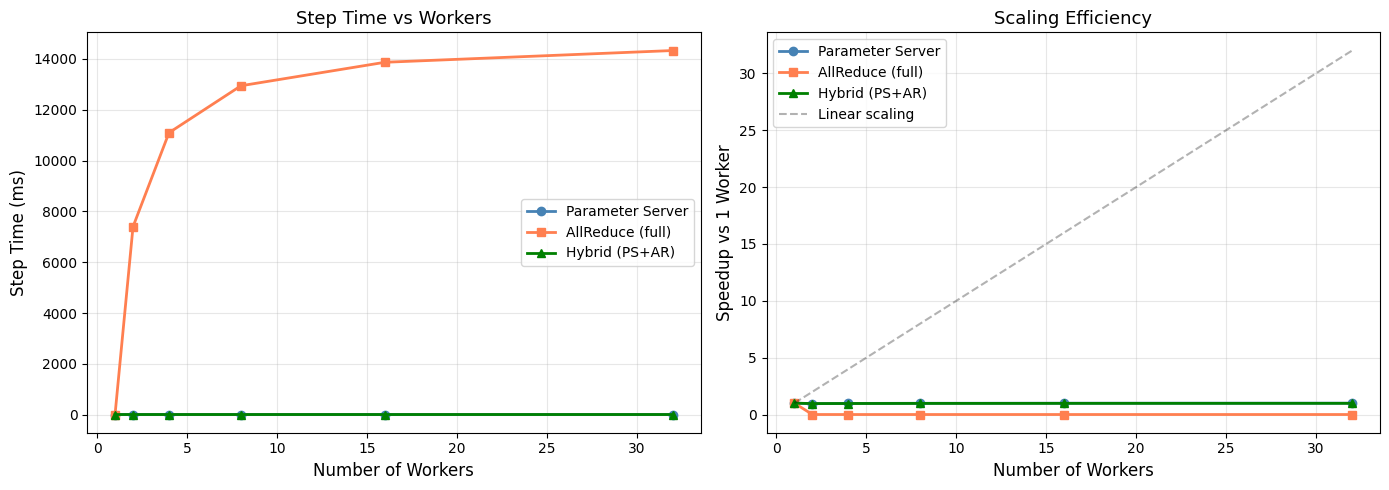

In [8]:
class DistributedTrainingSimulator:
    """Simulate communication costs for PS vs AllReduce."""
    
    def __init__(self, num_workers: int, bandwidth_gbps: float = 100.0):
        self.num_workers = num_workers
        self.bw = bandwidth_gbps * 1e9 / 8  # bytes per second
    
    def ps_step_time(self, batch_size: int, num_tables: int, avg_emb_dim: int,
                     unique_ratio: float = 0.5, compute_time_ms: float = 10.0) -> float:
        """Estimate step time with parameter server."""
        # Pull: each worker pulls B * num_tables embeddings
        pull_bytes = batch_size * num_tables * avg_emb_dim * 4
        # Push: only unique IDs
        unique_per_worker = int(batch_size * num_tables * unique_ratio)
        push_bytes = unique_per_worker * avg_emb_dim * 4
        
        comm_time_ms = (pull_bytes + push_bytes) / self.bw * 1000
        return compute_time_ms + comm_time_ms
    
    def allreduce_step_time(self, total_params: int, 
                            compute_time_ms: float = 10.0) -> float:
        """Estimate step time with AllReduce."""
        # Ring AllReduce: 2*(N-1)/N * M
        comm_bytes = 2 * (self.num_workers - 1) / self.num_workers * total_params * 4
        comm_time_ms = comm_bytes / self.bw * 1000
        return compute_time_ms + comm_time_ms
    
    def hybrid_step_time(self, batch_size: int, num_tables: int, avg_emb_dim: int,
                         mlp_params: int, unique_ratio: float = 0.5,
                         compute_time_ms: float = 10.0) -> float:
        """Hybrid: PS for embeddings + AllReduce for MLP."""
        # Embedding comm (all-to-all style)
        emb_bytes = batch_size * num_tables * avg_emb_dim * 4 * 2  # fwd + bwd
        emb_comm_ms = emb_bytes * (self.num_workers - 1) / self.num_workers / self.bw * 1000
        
        # MLP AllReduce
        mlp_bytes = 2 * (self.num_workers - 1) / self.num_workers * mlp_params * 4
        mlp_comm_ms = mlp_bytes / self.bw * 1000
        
        return compute_time_ms + emb_comm_ms + mlp_comm_ms


# Compare across different configurations
worker_counts = [1, 2, 4, 8, 16, 32]
batch_size = 4096
num_tables_cfg = 10
avg_dim = 48
mlp_params_total = mlp_param_count
total_emb_params = sum(r * d for _, r, d in tables)

ps_times = []
ar_times = []
hybrid_times = []

for nw in worker_counts:
    if nw == 1:
        ps_times.append(10.0)
        ar_times.append(10.0)
        hybrid_times.append(10.0)
        continue
    
    sim = DistributedTrainingSimulator(nw, bandwidth_gbps=100.0)
    ps_times.append(sim.ps_step_time(batch_size // nw, num_tables_cfg, avg_dim))
    ar_times.append(sim.allreduce_step_time(total_emb_params + mlp_params_total))
    hybrid_times.append(sim.hybrid_step_time(batch_size // nw, num_tables_cfg, avg_dim, mlp_params_total))

# Throughput (samples per second)
ps_throughput = [batch_size / (t / 1000) for t in ps_times]
ar_throughput = [batch_size / (t / 1000) for t in ar_times]
hybrid_throughput = [batch_size / (t / 1000) for t in hybrid_times]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(worker_counts, ps_times, 'o-', label='Parameter Server', linewidth=2, color='steelblue')
axes[0].plot(worker_counts, ar_times, 's-', label='AllReduce (full)', linewidth=2, color='coral')
axes[0].plot(worker_counts, hybrid_times, '^-', label='Hybrid (PS+AR)', linewidth=2, color='green')
axes[0].set_xlabel('Number of Workers', fontsize=12)
axes[0].set_ylabel('Step Time (ms)', fontsize=12)
axes[0].set_title('Step Time vs Workers', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(worker_counts, [t / ps_throughput[0] for t in ps_throughput], 'o-', 
             label='Parameter Server', linewidth=2, color='steelblue')
axes[1].plot(worker_counts, [t / ar_throughput[0] for t in ar_throughput], 's-', 
             label='AllReduce (full)', linewidth=2, color='coral')
axes[1].plot(worker_counts, [t / hybrid_throughput[0] for t in hybrid_throughput], '^-',
             label='Hybrid (PS+AR)', linewidth=2, color='green')
axes[1].plot(worker_counts, worker_counts, 'k--', alpha=0.3, label='Linear scaling')
axes[1].set_xlabel('Number of Workers', fontsize=12)
axes[1].set_ylabel('Speedup vs 1 Worker', fontsize=12)
axes[1].set_title('Scaling Efficiency', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🏋️ Exercise 1: Implement Embedding Table Sharding

Implement a `ShardedEmbeddingTable` that distributes rows across simulated GPUs and performs lookup with inter-GPU communication tracking.

In [9]:
# 🏋️ Exercise 1: Sharded Embedding Table

class ShardedEmbeddingTable:
    def __init__(self, num_items: int, embedding_dim: int, num_shards: int):
        """
        Row-wise sharded embedding table.
        
        Args:
            num_items: Total number of items
            embedding_dim: Embedding dimension
            num_shards: Number of GPU shards
        """
        # TODO: Create num_shards embedding tables, each holding num_items // num_shards rows
        # TODO: Track communication volume
        pass
    
    def lookup(self, item_ids: torch.Tensor, requesting_shard: int) -> torch.Tensor:
        """
        Look up embeddings, tracking inter-shard communication.
        
        Args:
            item_ids: (B,) tensor of item IDs
            requesting_shard: ID of the shard making the request
        
        Returns:
            (B, D) tensor of embeddings
        """
        # TODO: 
        # 1. Determine which shard each item belongs to
        # 2. Look up locally stored items directly
        # 3. Track communication for remote lookups
        # 4. Return all embeddings in order
        pass
    
    def get_comm_stats(self) -> Dict:
        """Return communication statistics."""
        # TODO: Return local vs remote lookup counts and bytes transferred
        pass


# Test:
# sharded = ShardedEmbeddingTable(100000, 64, num_shards=4)
# ids = torch.randint(0, 100000, (256,))
# embs = sharded.lookup(ids, requesting_shard=0)
# print(f"Embedding shape: {embs.shape}")
# print(f"Comm stats: {sharded.get_comm_stats()}")

## 🏋️ Exercise 2: Simulate Hybrid Parallel Training

Build a simulator that trains a two-tower rec model using hybrid parallelism:
- Embeddings: model-parallel (sharded across simulated workers)
- MLP: data-parallel (gradients synchronized via AllReduce)

In [10]:
# 🏋️ Exercise 2: Hybrid parallel training simulator

class HybridParallelSimulator:
    def __init__(self, num_workers: int, num_items: int, embedding_dim: int,
                 mlp_layers: List[int]):
        """
        Simulate hybrid parallel training.
        
        Args:
            num_workers: Number of simulated workers
            num_items: Number of items for embedding table
            embedding_dim: Dimension of embeddings
            mlp_layers: MLP architecture
        """
        # TODO:
        # 1. Create sharded embedding tables (one shard per worker)
        # 2. Create replicated MLP on each worker
        # 3. Set up communication tracking
        pass
    
    def train_step(self, user_ids: torch.Tensor, item_ids: torch.Tensor,
                   labels: torch.Tensor) -> float:
        """
        Execute one training step with hybrid parallelism.
        
        Returns:
            Training loss
        """
        # TODO:
        # 1. Split batch across workers (data parallel)
        # 2. Each worker does embedding lookup (some remote)
        # 3. Each worker computes MLP forward + loss
        # 4. Backward pass
        # 5. AllReduce MLP gradients
        # 6. Local embedding gradient updates
        pass


# Test:
# sim = HybridParallelSimulator(num_workers=4, num_items=10000, embedding_dim=32, mlp_layers=[64, 32, 1])
# users = torch.randint(0, 1000, (256,))
# items = torch.randint(0, 10000, (256,))
# labels = torch.randint(0, 2, (256,)).float()
# loss = sim.train_step(users, items, labels)
# print(f"Training loss: {loss:.4f}")

## 🏋️ Exercise 3: Communication Cost Analyzer

Build a tool that takes a model configuration and cluster setup, then recommends the optimal parallelism strategy.

In [11]:
# 🏋️ Exercise 3: Communication cost analyzer

def analyze_optimal_strategy(
    embedding_tables: List[Tuple[int, int]],
    mlp_params: int,
    batch_size: int,
    num_workers: int,
    bandwidth_gbps: float = 100.0
) -> Dict:
    """
    Analyze and recommend the optimal distributed training strategy.
    
    Args:
        embedding_tables: List of (num_rows, embedding_dim)
        mlp_params: Total MLP parameters
        batch_size: Global batch size
        num_workers: Number of workers
        bandwidth_gbps: Network bandwidth
    
    Returns:
        Dict with analysis results and recommendation
    """
    # TODO:
    # 1. Compute memory requirements
    # 2. Check if full replication is possible (fits in GPU memory)
    # 3. Estimate comm cost for: data-parallel, model-parallel, hybrid
    # 4. Return recommendation with reasoning
    pass


# Test:
# result = analyze_optimal_strategy(
#     embedding_tables=[(1_000_000, 64), (10_000_000, 64), (100_000, 32)],
#     mlp_params=100000,
#     batch_size=4096,
#     num_workers=8
# )
# print(f"Recommendation: {result}")

## Summary

| Topic | Key Takeaway |
|-------|--------------|
| **Parameter Server** | Best for sparse embeddings; allows partial updates but can bottleneck |
| **AllReduce** | Best for dense MLP parameters; near-linear scaling with ring topology |
| **Table Sharding** | Row-wise + replication hybrid gives best memory balance |
| **Hybrid Parallelism** | Production standard: model-parallel embeddings + data-parallel MLP |
| **Hierarchical Storage** | Hot/cold embedding tiering (GPU/CPU/SSD) reduces memory requirements |
| **Production Platforms** | ZionEX (Meta), Persia (Kuaishou), HET (Tencent) push the state of the art |

### Key References
- Li et al., "Scaling Distributed Machine Learning with the Parameter Server" (2014, CMU/Baidu)
- Naumov et al., "Deep Learning Recommendation Model for Personalization and Recommendation Systems" (2019, Meta — DLRM)
- Luo et al., "Persia: An Open, Hybrid System Scaling Deep Learning-based Recommenders up to 100 Trillion Parameters" (2022, Kuaishou)
- Liang et al., "HET: Scaling out Huge Embedding Model Training via Cache-Enabled Distributed Framework" (2022, Tencent)
- Mudigere et al., "Software-Hardware Co-design for Fast and Scalable Training of Deep Learning Recommendation Models" (2022, Meta — ZionEX)

### Next Steps
In the next notebook (9.3), we will explore mixed-precision training and quantization techniques specifically optimized for recommendation models.